In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
customers_df_c = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\cleaned_datasets\customers.csv")
orders_df_c = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\cleaned_datasets\orders.csv")
products_df_c = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\cleaned_datasets\products.csv")
sellers_df_c = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\cleaned_datasets\sellers.csv")
order_payments_df_c = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\cleaned_datasets\order_payments.csv")
order_reviews_df_c = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\cleaned_datasets\order_reviews.csv")
order_items_df_c = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\cleaned_datasets\order_items.csv")
product_category_transalation_df_c = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\cleaned_datasets\product_category_translation.csv")
geolocation_df_c = pd.read_csv(r"D:\Sasi\GUVI HCL AI-ML\Cart2Insights_Project\data\cleaned_datasets\geolocation.csv")

In [8]:
#Monthly sales over years
sales_df = pd.merge(orders_df_c,order_payments_df_c,on='order_id',how='inner')
sales_df['order_purchase_timestamp'] = pd.to_datetime(sales_df['order_purchase_timestamp'])
sales_df['year_month'] = sales_df['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = sales_df.groupby('year_month',as_index=False)['payment_value'].sum()
monthly_sales.columns = ['Month', 'Total Sales']
monthly_sales

,Month,Total Sales
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


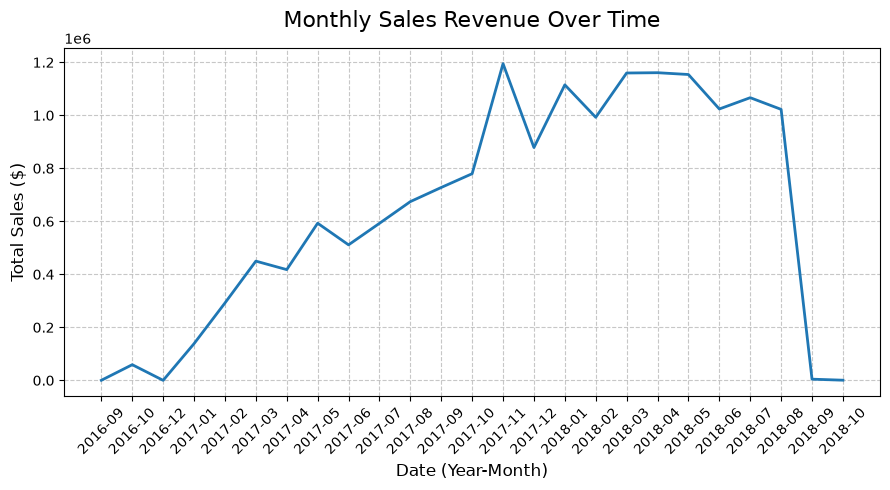

In [7]:
monthly_sales['Month'] = monthly_sales['Month'].astype(str)
plt.figure(figsize=(9,5))
sns.lineplot(data=monthly_sales,x='Month',y='Total Sales',markers='o',linewidth=2)
plt.title('Monthly Sales Revenue Over Time', fontsize=16, pad=15)
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Sales were near zero through late 2016,starting in early 2017 (2017-01), sales experienced continuous upward momentum, climbing from ~$200K to nearly ~$800K by October 2017.
- Sales spiked drastically in 2017-11 to reach the peak of ~$1.2 Million.
- Between March 2018 and August 2018, sales consistently fluctuated at a strong range between $1.0M and $1.15M monthly, indicating steady market demand.
- The steep decline from 2018-08 is maybe due to an incomplete data issue.

In [24]:
# Item price vs its sales
item_price_merged = order_items_df_c.merge(products_df_c,on='product_id',how='left')
item_price_merged = pd.merge(item_price_merged, product_category_transalation_df_c, on='product_category_name', how='left')
item_price_summary = item_price_merged.groupby(['product_id', 'product_category_name_english']).agg(unit_price=('price', 'mean'),units_sold=('order_item_id', 'count'),total_sales=('price', 'sum')).reset_index()
item_price_summary.sort_values(by='total_sales',ascending=False)



,product_id,product_category_name_english,unit_price,units_sold,total_sales
23640,bb50f2e236e5eea0100680137654686c,health_beauty,327.615385,195,63885.00
13807,6cdd53843498f92890544667809f1595,health_beauty,350.834615,156,54730.20
27101,d6160fb7873f184099d9bc95e30376af,computers,1397.124000,35,48899.34
26532,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,137.651633,343,47214.51
19386,99a4788cb24856965c36a24e339b6058,bed_bath_table,88.167131,488,43025.56
...,...,...,...,...,...
5965,2e8316b31db34314f393806fd7b6e185,stationery,2.990000,1,2.99
13212,680cc8535be7cc69544238c1d6a83fe8,pet_shop,2.900000,1,2.90
17447,8a3254bee785a526d548a81a9bc3c9be,construction_tools_construction,0.850000,3,2.55
6265,310dc32058903b6416c71faff132df9e,stationery,2.290000,1,2.29


In [17]:
category_price_summary = item_price_merged.groupby(['product_category_name_english']).agg(unit_price=('price', 'mean'),units_sold=('order_item_id', 'count'),total_sales=('price', 'sum')).reset_index()
category_price_summary.sort_values(by='total_sales',ascending=False,inplace=True)
category_price_summary

,product_category_name_english,unit_price,units_sold,total_sales
43,health_beauty,130.163531,9670,1258681.34
70,watches_gifts,201.135984,5991,1205005.68
7,bed_bath_table,93.296327,11115,1036988.68
65,sports_leisure,114.344285,8641,988048.97
15,computers_accessories,116.513903,7827,911954.32
...,...,...,...,...
35,flowers,33.637576,33,1110.04
46,home_comfort_2,25.342333,30,760.27
11,cds_dvds_musicals,52.142857,14,730.00
29,fashion_childrens_clothes,71.231250,8,569.85


C:\Users\ssasi\AppData\Local\Temp\ipykernel_23880\296350104.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_price_summary,x='total_sales',y='product_category_name_english',palette='Blues_r')


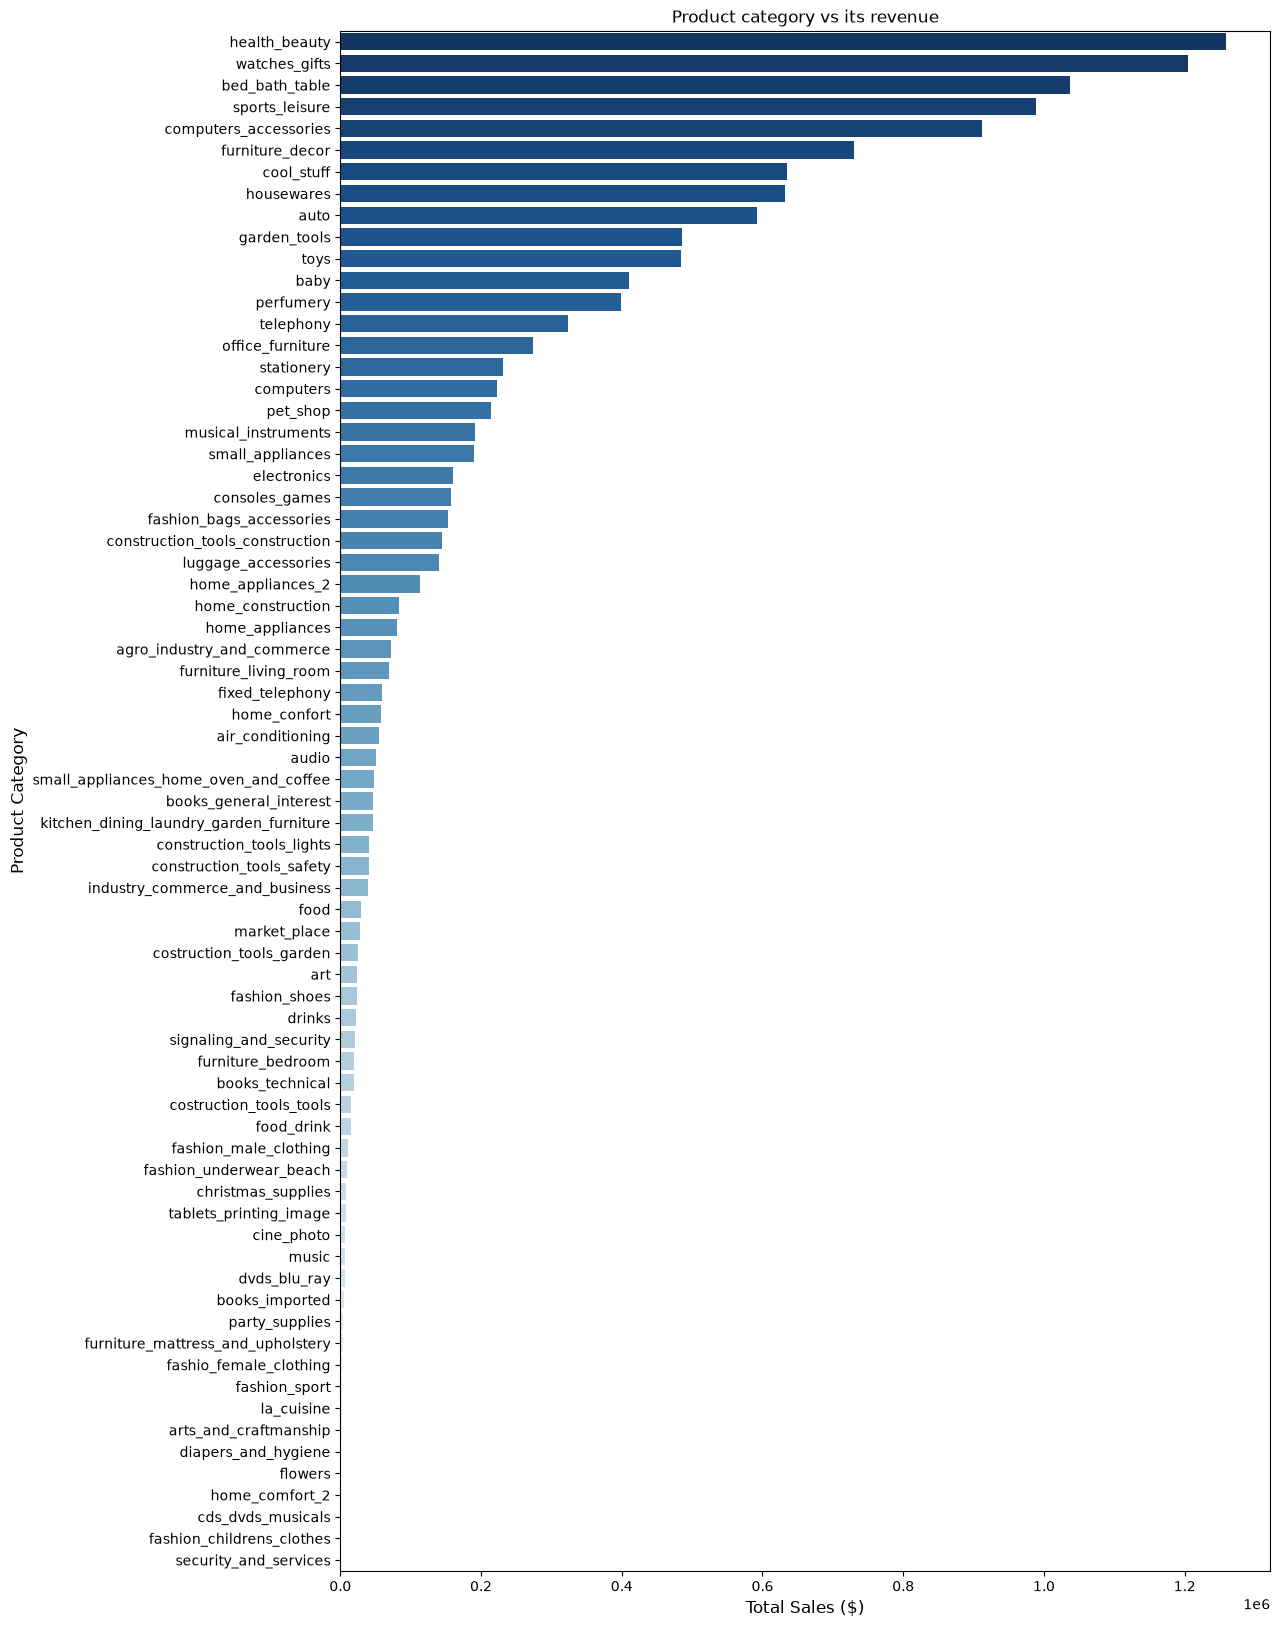

In [23]:
plt.figure(figsize=(12, 20))
sns.barplot(data=category_price_summary,x='total_sales',y='product_category_name_english',palette='Blues_r')
plt.title('Product category vs its revenue')
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.show()

In [30]:
# Product sales count vs Price
salescount_price_df = item_price_summary.sort_values(by='units_sold',ascending=False)
display(salescount_price_df)

,product_id,product_category_name_english,unit_price,units_sold,total_sales
21715,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,71.364137,527,37608.90
19386,99a4788cb24856965c36a24e339b6058,bed_bath_table,88.167131,488,43025.56
8452,422879e10f46682990de24d770e7f83d,garden_tools,54.911612,484,26577.22
7227,389d119b48cf3043d311335e499d9c6b,garden_tools,54.695383,392,21440.59
6946,368c6c730842d78016ad823897a372db,garden_tools,54.270103,388,21056.80
...,...,...,...,...,...
15,002552c0663708129c0019cc97552d7d,cool_stuff,108.000000,1,108.00
13,0021a87d4997a48b6cef1665602be0f5,computers_accessories,29.000000,1,29.00
10,001c5d71ac6ad696d22315953758fa04,bed_bath_table,79.900000,1,79.90
8,001b237c0e9bb435f2e54071129237e9,bed_bath_table,78.900000,1,78.90


In [33]:
# Products in unit price order
products_price_order = item_price_summary.sort_values(by='unit_price',ascending=False)
products_price_order

,product_id,product_category_name_english,unit_price,units_sold,total_sales
9252,489ae2aa008f021502940f251d4cce7f,housewares,6735.00,1,6735.00
13437,69c590f7ffc7bf8db97190b6cb6ed62e,computers,6729.00,1,6729.00
3622,1bdf5e6731585cf01aa8169c7028d6ad,art,6499.00,1,6499.00
20931,a6492cc69376c469ab6f61d8f44de961,small_appliances,4799.00,1,4799.00
24723,c3ed642d592594bb648ff4a04cee2747,small_appliances,4690.00,1,4690.00
...,...,...,...,...,...
6265,310dc32058903b6416c71faff132df9e,stationery,2.29,1,2.29
9060,46fce52cef5caa7cc225a5531c946c8b,health_beauty,2.20,1,2.20
685,05b515fdc76e888aada3c6d66c201dff,health_beauty,1.20,10,12.00
5060,270516a3f41dc035aa87d220228f844c,health_beauty,1.20,10,12.00


In [42]:
# Product size vs its sales
df_item_size = pd.merge(item_price_summary,products_df_c, on='product_id', how='inner')
df_item_size['product_volume_cm3'] = (df_item_size['product_length_cm']* df_item_size['product_width_cm']* df_item_size['product_height_cm'])
product_metrics = df_item_size[[
    'product_id',
    'product_category_name_english',
    'total_sales',
    'units_sold',
    'product_volume_cm3',
    'product_weight_g',
]].sort_values(by='product_volume_cm3',ascending=False)
product_metrics

,product_id,product_category_name_english,total_sales,units_sold,product_volume_cm3,product_weight_g
26498,256a9c364b75753b97bee410c9491ad8,housewares,1149.00,1,296208.0,25250.0
10784,0b48eade13cfad433122f23739a66898,furniture_decor,1029.76,2,294000.0,14000.0
30625,f227e2d44f10f7dad30fb4dfa839e7a2,furniture_living_room,569.90,1,294000.0,30000.0
22519,3eb14e65e4208c6d94b7a32e41add538,furniture_living_room,698.90,1,294000.0,30000.0
24474,c1e0531cb1864fd3a0cae57dca55ca80,furniture_living_room,569.90,1,294000.0,30000.0
...,...,...,...,...,...,...
2750,e6609e94d7b022fd6abf6142401618f9,fashion_bags_accessories,247.68,7,352.0,150.0
2361,7932fcce65e2aee84d6feb4a288f9cb9,fashion_underwear_beach,47.20,8,352.0,200.0
23962,35f00e354f3d048167beb8586eaf031b,fashion_bags_accessories,29.90,1,352.0,200.0
24971,2f763ba79d9cd987b2034aac7ceffe06,electronics,469.00,1,288.0,595.0


In [46]:
# Product size vs freight value
df_freight = item_price_merged.copy()
df_freight['product_volume_cm3'] = (df_freight['product_length_cm']* df_freight['product_width_cm']* df_freight['product_height_cm'])
volume_freight_summary = df_freight.groupby(['product_id','product_category_name_english']).agg(volume_cm3=('product_volume_cm3', 'first'),weight_g=('product_weight_g', 'first'),avg_freight_value=('freight_value', 'mean'),total_items_shipped=('order_item_id', 'count'),).reset_index()
volume_freight_summary.sort_values(by='volume_cm3',ascending=False)

,product_id,product_category_name_english,volume_cm3,weight_g,avg_freight_value,total_items_shipped
4855,256a9c364b75753b97bee410c9491ad8,housewares,296208.0,25250.0,339.59,1
8012,3eb14e65e4208c6d94b7a32e41add538,furniture_living_room,294000.0,30000.0,120.19,1
1424,0b48eade13cfad433122f23739a66898,furniture_decor,294000.0,14000.0,163.52,2
24469,c1e0531cb1864fd3a0cae57dca55ca80,furniture_living_room,294000.0,30000.0,119.29,1
30605,f227e2d44f10f7dad30fb4dfa839e7a2,furniture_living_room,294000.0,30000.0,119.29,1
...,...,...,...,...,...,...
8579,431772d0bf9d5e9a46fc78cb834a28ee,watches_gifts,352.0,250.0,14.65,2
7259,38e19855caf485b504d6f33ed31a9eb4,furniture_decor,352.0,400.0,8.54,2
18816,954ed36fcf28237749ef5616ab0eff87,fashion_bags_accessories,352.0,150.0,15.15,2
6074,2f763ba79d9cd987b2034aac7ceffe06,electronics,288.0,595.0,20.85,1


In [55]:
# Customer distribution
customer_dist = customers_df_c.groupby(['customer_city','customer_state']).agg(customer_count = ('customer_id','count')).reset_index()
customer_dist['percentage'] = (customer_dist['customer_count'] / customer_dist['customer_count'].sum()) * 100
customer_dist.sort_values(by='customer_count',ascending=False)

,customer_city,customer_state,customer_count,percentage
3758,sao paulo,SP,15540,15.627357
3281,rio de janeiro,RJ,6882,6.920687
469,belo horizonte,MG,2773,2.788588
587,brasilia,DF,2131,2.142979
1187,curitiba,PR,1521,1.529550
...,...,...,...,...
4304,xexeu,PE,1,0.001006
26,adrianopolis,PR,1,0.001006
27,adustina,BA,1,0.001006
31,agisse,SP,1,0.001006


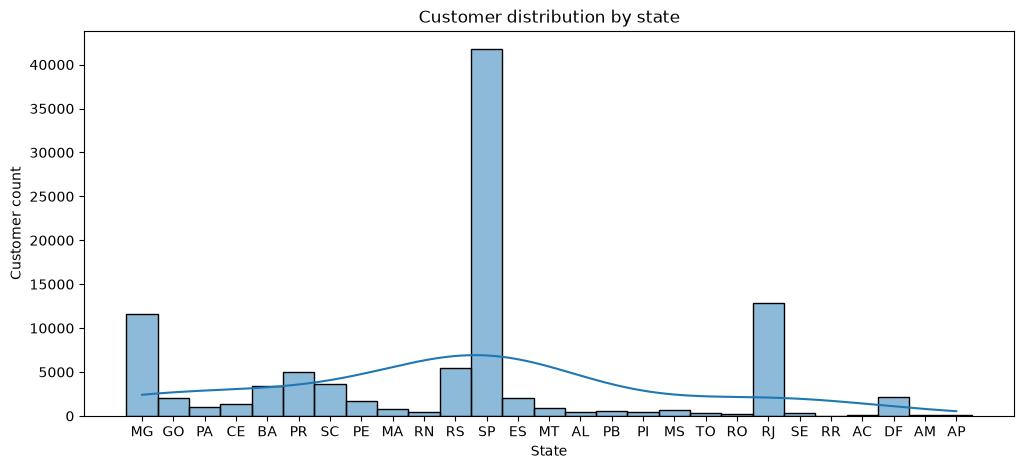

In [62]:
plt.figure(figsize=(12,5))
sns.histplot(data=customer_dist,x='customer_state',weights='customer_count',discrete=True,kde=True)
plt.title('Customer distribution by state')
plt.xlabel('State')
plt.ylabel('Customer count')
plt.show()

In [65]:
#Seller distribution
seller_dist = sellers_df_c.groupby(['seller_city','seller_state']).agg(seller_count=('seller_id','count')).reset_index()
seller_dist['percentage'] = (seller_dist['seller_count'] / seller_dist['seller_count'].sum()) * 100
seller_dist.sort_values(by='seller_count',ascending=False)

,seller_city,seller_state,seller_count,percentage
540,sao paulo,SP,694,22.423263
164,curitiba,PR,124,4.006462
470,rio de janeiro,RJ,93,3.004847
65,belo horizonte,MG,66,2.132472
461,ribeirao preto,SP,52,1.680129
...,...,...,...,...
33,arinos,MG,1,0.032310
595,tres coroas,RS,1,0.032310
596,tres de maio,RS,1,0.032310
597,tres rios,RJ,1,0.032310


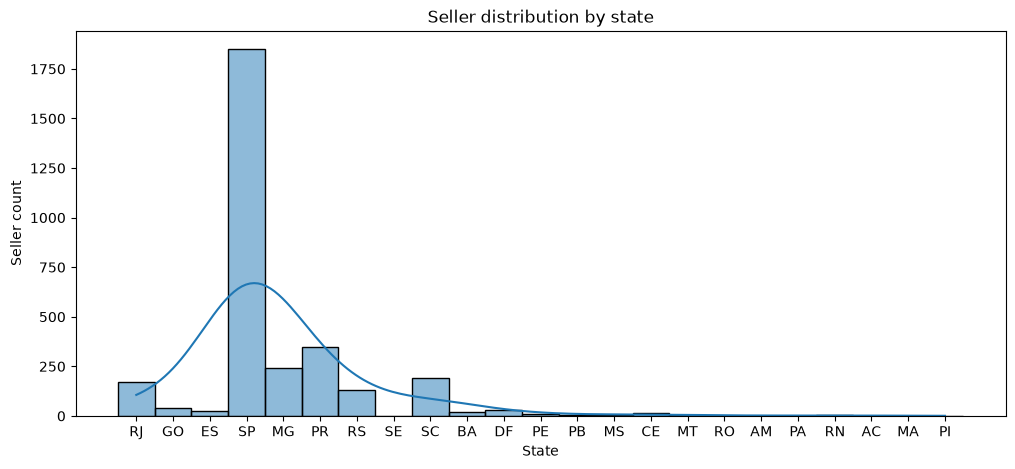

In [67]:
plt.figure(figsize=(12,5))
sns.histplot(data=seller_dist,x='seller_state',weights='seller_count',discrete=True,kde=True)
plt.title('Seller distribution by state')
plt.xlabel('State')
plt.ylabel('Seller count')
plt.show()

In [79]:
# Customer and seller statewise comparison
customer_state = customer_dist.groupby('customer_state').agg(customer_count = ('customer_count','sum')).reset_index()
seller_state = seller_dist.groupby('seller_state').agg(seller_count = ('seller_count','sum')).reset_index()
statewise_list = pd.merge(customer_state,seller_state,left_on='customer_state',right_on='seller_state',how='outer')
statewise_list['state']= statewise_list['customer_state'].fillna(statewise_list['seller_state'])
statewise_list = statewise_list.drop(columns=['customer_state', 'seller_state'])
statewise_list['customer_count'] = statewise_list['customer_count'].fillna('0').astype('int64')
statewise_list['seller_count'] = statewise_list['seller_count'].fillna('0').astype('int64')
statewise_list.sort_values(by='customer_count', ascending=False).reset_index(drop=True)

,customer_count,seller_count,state
0,41746,1849,SP
1,12852,171,RJ
2,11635,244,MG
3,5466,129,RS
4,5045,349,PR
5,3637,190,SC
6,3380,19,BA
7,2140,30,DF
8,2033,23,ES
9,2020,40,GO


In [ ]:
# Seller city vs total items sold
df_city_category_freight = (order_items_df_c.merge(sellers_df_c, on='seller_id', how='inner').merge(products_df_c, on='product_id', how='inner')
    .merge(product_category_transalation_df_c, on='product_category_name', how='left')
)
city_category_summary = (df_city_category_freight.groupby(['seller_city','seller_state','product_category_name_english',]).agg(
        total_items_sold=('order_id', 'count'),
        avg_freight_value=('freight_value', 'mean'),
        avg_price=('price', 'mean'),
    ).reset_index())

city_category_summary['city_state'] = (city_category_summary['seller_city']+ ' ('+ city_category_summary['seller_state']+ ')')

city_category_summary = city_category_summary.sort_values(by='total_items_sold', ascending=False).reset_index(drop=True)

city_category_summary

,seller_city,seller_state,product_category_name_english,total_items_sold,avg_freight_value,avg_price,city_state
0,ibitinga,SP,bed_bath_table,6039,17.886615,83.429316,ibitinga (SP)
1,sao paulo,SP,telephony,2930,14.463058,33.823246,sao paulo (SP)
2,sao paulo,SP,furniture_decor,2912,19.579337,89.243695,sao paulo (SP)
3,sao paulo,SP,cool_stuff,1970,19.450853,145.285142,sao paulo (SP)
4,sao paulo,SP,housewares,1938,17.618560,81.599082,sao paulo (SP)
...,...,...,...,...,...,...,...
3210,americana,SP,industry_commerce_and_business,1,12.400000,99.990000,americana (SP)
3211,viana,ES,auto,1,53.040000,98.000000,viana (ES)
3212,viamao,RS,fashio_female_clothing,1,15.200000,65.000000,viamao (RS)
3213,vespasiano,MG,construction_tools_lights,1,25.120000,399.500000,vespasiano (MG)


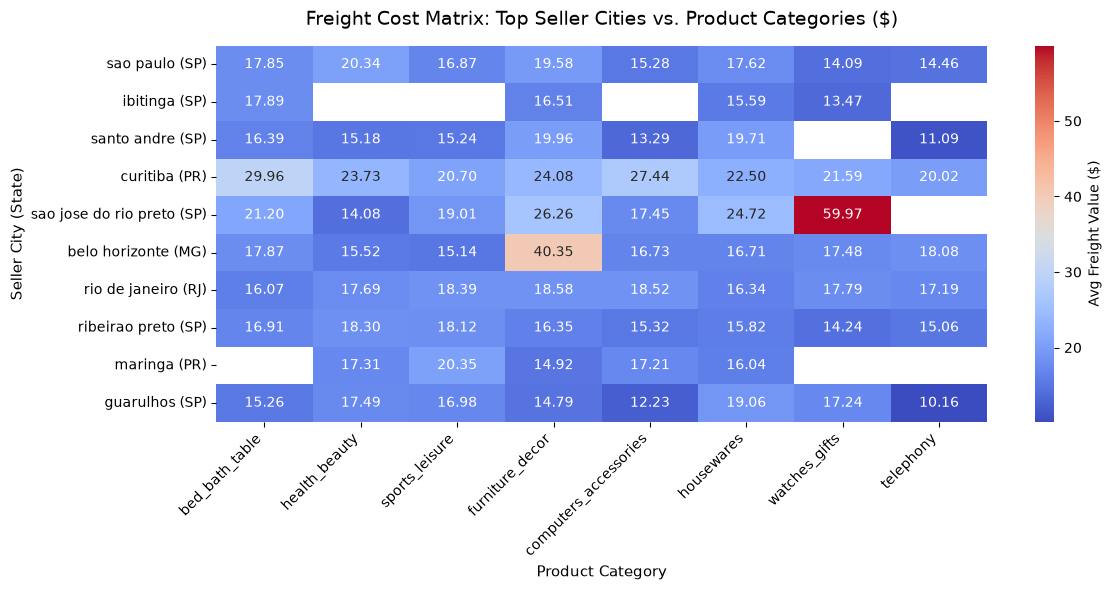

In [83]:
heatmap_data = city_category_summary.pivot_table(index='city_state',columns='product_category_name_english',values='avg_freight_value',aggfunc='mean',)
top_cities_list = (city_category_summary.groupby('city_state')['total_items_sold'].sum().nlargest(10).index)
top_cats_list = (city_category_summary.groupby('product_category_name_english')['total_items_sold'].sum().nlargest(8).index)
heatmap_subset = heatmap_data.loc[top_cities_list, top_cats_list]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_subset,annot=True,fmt='.2f',cmap='coolwarm',cbar_kws={'label': 'Avg Freight Value ($)'},)
plt.title('Freight Cost Matrix: Top Seller Cities vs. Product Categories ($)',fontsize=14,pad=15,)
plt.xlabel('Product Category', fontsize=11)
plt.ylabel('Seller City (State)', fontsize=11)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [81]:
# Seller city vs freight value
city_category_summary.sort_values(by='avg_freight_value',ascending=False)

,seller_city,seller_state,product_category_name_english,total_items_sold,avg_freight_value,avg_price,city_state
3126,goiania,GO,art,1,227.660000,6499.00,goiania (GO)
2834,sao paulo - sp,SP,furniture_decor,1,215.430000,74.90,sao paulo - sp (SP)
2189,sorocaba,SP,musical_instruments,2,215.035000,1350.00,sorocaba (SP)
2079,varginha,MG,industry_commerce_and_business,2,205.865000,980.90,varginha (MG)
3153,pinhais,SP,health_beauty,1,193.280000,680.00,pinhais (SP)
...,...,...,...,...,...,...,...
2799,novo hamburgo,RS,pet_shop,1,6.660000,29.90,novo hamburgo (RS)
1320,tres rios,RJ,furniture_decor,7,6.471429,11.24,tres rios (RJ)
1599,tatui,SP,construction_tools_construction,5,4.950000,35.90,tatui (SP)
3001,foz do iguacu,PR,market_place,1,4.860000,74.90,foz do iguacu (PR)


In [103]:
# On time vs delayed delivery
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_df_c[col] = pd.to_datetime(orders_df_c[col])

orders_df_c['estimated_delivery_days'] = (orders_df_c['order_estimated_delivery_date'] - orders_df_c['order_purchase_timestamp']).dt.days
orders_df_c['actual_delivery_days'] = (orders_df_c['order_delivered_customer_date'] - orders_df_c['order_purchase_timestamp']).dt.days
orders_df_c['seller_handling_days'] = (orders_df_c['order_delivered_carrier_date'] - orders_df_c['order_purchase_timestamp']).dt.days
orders_df_c['carrier2customer_delivery_days'] = (orders_df_c['order_delivered_customer_date'] - orders_df_c['order_delivered_carrier_date']).dt.days
orders_df_c['delay'] = (orders_df_c['order_delivered_customer_date']-orders_df_c['order_estimated_delivery_date']).dt.days
orders_df_c['is_delayed'] = orders_df_c['delay'] > 0
orders_df_c.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,estimated_delivery_days,actual_delivery_days,seller_handling_days,carrier2customer_delivery_days,delay,is_delayed
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,15,8.0,2.0,6.0,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,19,13.0,1.0,12.0,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,26,9.0,0.0,9.0,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,26,13.0,3.0,9.0,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,12,2.0,0.0,1.0,-10.0,False


In [89]:
on_time_summary = {'Total Delivered Orders': orders_df_c['actual_delivery_days'].count(),
    'On-time delivery count':orders_df_c[orders_df_c['delay']<=0]['delay'].count(),
    'Delayed delivery count':orders_df_c[orders_df_c['delay']>0]['delay'].count(),
    'On-Time Delivery Rate (%)': (orders_df_c['delay'] <= 0).mean()* 100,
    'Avg Actual Delivery (Days)': orders_df_c['actual_delivery_days'].mean(),
    'Avg Estimated Delivery (Days)': orders_df_c['estimated_delivery_days'].mean(),
    'Avg Seller Handling (Days)': orders_df_c['seller_handling_days'].mean(),
    'Avg Carrier Transit (Days)': orders_df_c['carrier2customer_delivery_days'].mean(),
    'Avg Delay when Late (Days)': orders_df_c[orders_df_c['delay'] > 0]['delay'].mean(),}

pd.Series(on_time_summary).round(2)

Total Delivered Orders           96453.00
On-time delivery count           89918.00
Delayed delivery count            6535.00
On-Time Delivery Rate (%)           90.42
Avg Actual Delivery (Days)          12.10
Avg Estimated Delivery (Days)       23.40
Avg Seller Handling (Days)           2.77
Avg Carrier Transit (Days)           8.91
Avg Delay when Late (Days)          10.62
dtype: float64

In [104]:
# Shipping Lead Times & Delay Rate by Customer State
orders_geo = pd.merge(orders_df_c,customers_df_c[['customer_id', 'customer_state']],on='customer_id',how='inner',)
state_logistics = (orders_geo.groupby('customer_state').agg(total_orders=('order_id', 'count'),
        avg_carrier_days=('carrier2customer_delivery_days', 'mean'),
        avg_actual_days=('actual_delivery_days', 'mean'),
        delay_rate_pct=('is_delayed',lambda x: (x.sum() / x.count()) * 100),).reset_index().sort_values(by='avg_carrier_days', ascending=False))
state_logistics

,customer_state,total_orders,avg_carrier_days,avg_actual_days,delay_rate_pct
21,RR,46,25.600000,28.975610,10.869565
3,AP,68,23.208955,26.731343,2.941176
2,AM,148,23.090278,25.986207,2.702703
1,AL,413,20.424936,24.040302,20.581114
13,PA,975,19.851496,23.316068,10.871795
9,MA,747,17.595745,21.117155,16.733601
5,CE,1336,17.579365,20.817826,13.173653
24,SE,350,17.555556,21.029851,14.571429
0,AC,81,17.233766,20.637500,3.703704
14,PB,536,16.514735,19.953578,10.074627


C:\Users\ssasi\AppData\Local\Temp\ipykernel_23880\3970415952.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=state_logistics.head(10),x='customer_state',y='avg_carrier_days',palette='Reds_r',ax=ax1,)


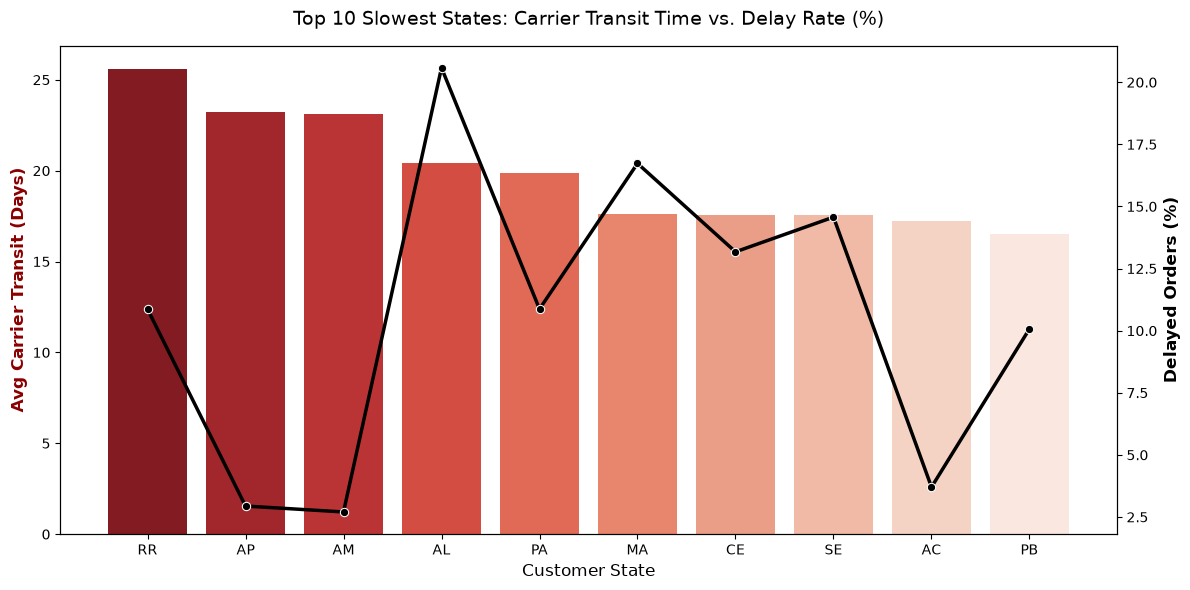

In [105]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Carrier Transit Days (Bar Chart)
ax1 = sns.barplot(data=state_logistics.head(10),x='customer_state',y='avg_carrier_days',palette='Reds_r',ax=ax1,)
ax1.set_ylabel('Avg Carrier Transit (Days)', color='darkred', fontsize=12, fontweight='bold')
ax1.set_xlabel('Customer State', fontsize=12)
# Secondary Axis: Late Delivery Rate % (Line Plot)
ax2 = ax1.twinx()
sns.lineplot(data=state_logistics.head(10),x='customer_state',y='delay_rate_pct',color='black',marker='o',linewidth=2.5,ax=ax2,)
ax2.set_ylabel('Delayed Orders (%)', color='black', fontsize=12, fontweight='bold')
plt.title('Top 10 Slowest States: Carrier Transit Time vs. Delay Rate (%)',fontsize=14,pad=15,)
plt.tight_layout()
plt.show()

In [97]:
#Seller Handling Speed vs. Compliance
seller_compliance = pd.merge(order_items_df_c[['order_id', 'seller_id', 'shipping_limit_date']],orders_df_c[['order_id','order_purchase_timestamp',
    'order_delivered_carrier_date','seller_handling_days']],on='order_id',how='inner')

seller_compliance['shipping_limit_date'] = pd.to_datetime(seller_compliance['shipping_limit_date'])

seller_compliance['dispatch_delay_days'] = (seller_compliance['order_delivered_carrier_date']- seller_compliance['shipping_limit_date']).dt.days

seller_compliance['is_seller_late'] = (seller_compliance['dispatch_delay_days'] > 0)

seller_performance = (seller_compliance.groupby('seller_id').agg(total_fulfilled=('order_id', 'count'),avg_handling_days=('seller_handling_days', 'mean'),
    late_dispatch_count=('is_seller_late', 'sum'),seller_late_pct=('is_seller_late',lambda x: (x.sum() / x.count()) * 100,),).reset_index())

seller_performance = pd.merge(seller_performance,sellers_df_c[['seller_id', 'seller_city', 'seller_state']],on='seller_id',how='left')
cols = ['seller_id','seller_city','seller_state','total_fulfilled','avg_handling_days','late_dispatch_count','seller_late_pct',]
seller_performance = seller_performance[cols]

seller_performance




,seller_id,seller_city,seller_state,total_fulfilled,avg_handling_days,late_dispatch_count,seller_late_pct
0,0015a82c2db000af6aaaf3ae2ecb0532,santo andre,SP,3,3.000000,0,0.000000
1,001cca7ae9ae17fb1caed9dfb1094831,cariacica,ES,239,2.133891,4,1.673640
2,001e6ad469a905060d959994f1b41e4f,sao goncalo,RJ,1,NaN,0,0.000000
3,002100f778ceb8431b7a1020ff7ab48f,franca,SP,55,4.090909,4,7.272727
4,003554e2dce176b5555353e4f3555ac8,goiania,GO,1,0.000000,0,0.000000
...,...,...,...,...,...,...,...
3090,ffcfefa19b08742c5d315f2791395ee5,curitiba,PR,1,NaN,0,0.000000
3091,ffdd9f82b9a447f6f8d4b91554cc7dd3,curitiba,PR,20,3.947368,0,0.000000
3092,ffeee66ac5d5a62fe688b9d26f83f534,mirassol,SP,14,6.428571,3,21.428571
3093,fffd5413c0700ac820c7069d66d98c89,amparo,SP,61,1.900000,2,3.278689


In [98]:
active_sellers = seller_performance[seller_performance['total_fulfilled'] >= 20].sort_values(by='seller_late_pct', ascending=False)

active_sellers

,seller_id,seller_city,seller_state,total_fulfilled,avg_handling_days,late_dispatch_count,seller_late_pct
863,48efc9d94a9834137efd9ea76b065a38,curitiba,PR,34,5.147059,28,82.352941
1847,973f21788dfab357250f69a8dcb7ddee,claudio,MG,21,10.842105,15,71.428571
1614,835f0f7810c76831d6c7d24c7a646d4d,sao paulo,SP,50,8.895833,30,60.000000
1032,54965bbe3e4f07ae045b90b0b8541f52,foz do iguacu,PR,86,16.493827,38,44.186047
351,1da366cade6d8276e7d8beea7af5d4bf,uba,MG,49,6.632653,21,42.857143
...,...,...,...,...,...,...,...
2982,f63d8f293af3a6454377546bd9dd19ff,votorantim,SP,28,6.500000,0,0.000000
2985,f67efa3f0b6761102a7f8c6b7b571f5d,curitiba,PR,32,2.031250,0,0.000000
2986,f680f85bee2d253556ac91be391d2c82,carapicuiba,SP,54,1.471698,0,0.000000
2993,f789d2c4f2c2eb38fc4373e7a4b35264,juiz de fora,MG,49,1.562500,0,0.000000


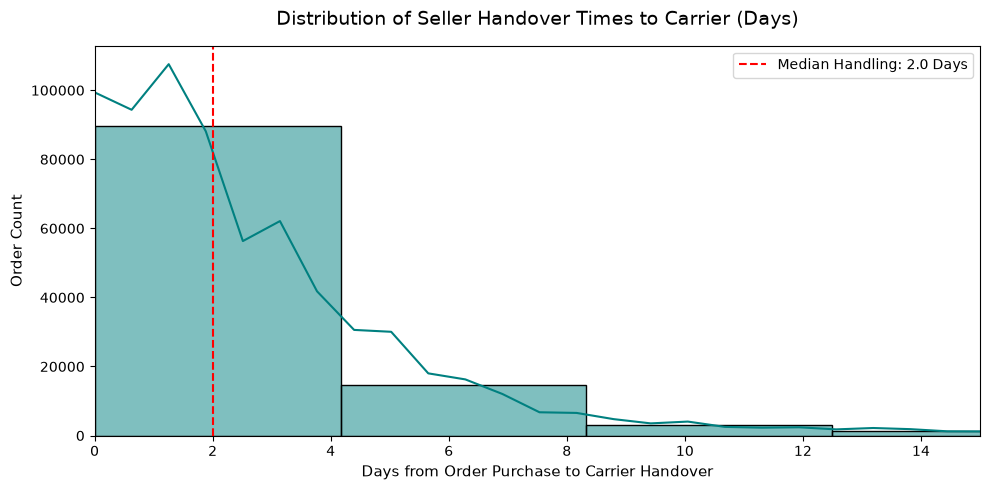

In [99]:
# Plot distribution of seller handling days
plt.figure(figsize=(10, 5))
sns.histplot(seller_compliance['seller_handling_days'].dropna(),bins=30,kde=True,color='teal',)
plt.axvline(seller_compliance['seller_handling_days'].median(),color='red',linestyle='--',label=f"Median Handling: {seller_compliance['seller_handling_days'].median():.1f} Days")
plt.title('Distribution of Seller Handover Times to Carrier (Days)',fontsize=14,pad=15,)
plt.xlabel('Days from Order Purchase to Carrier Handover', fontsize=11)
plt.ylabel('Order Count', fontsize=11)
plt.legend()
plt.xlim(0, 15)
plt.tight_layout()
plt.show()

In [100]:
city_compliance = (seller_performance.groupby(['seller_city', 'seller_state']).agg(total_active_sellers=('seller_id', 'count'),total_fulfilled=('total_fulfilled', 'sum'),
        city_avg_late_pct=('seller_late_pct', 'mean'),).reset_index().sort_values(by='total_fulfilled', ascending=False))

city_compliance

,seller_city,seller_state,total_active_sellers,total_fulfilled,city_avg_late_pct
540,sao paulo,SP,694,27983,6.763729
235,ibitinga,SP,49,7750,7.070451
505,santo andre,SP,45,2964,7.498372
164,curitiba,PR,124,2944,8.480836
529,sao jose do rio preto,SP,33,2579,6.363707
...,...,...,...,...,...
43,avare,SP,1,1,0.000000
254,irece,BA,1,1,0.000000
252,ipua,SP,1,1,0.000000
0,04482255,RJ,1,1,0.000000


In [111]:
# Delivery delays vs freight value
order_freight = (order_items_df_c.groupby('order_id').agg(total_freight=('freight_value', 'sum'),avg_item_freight=('freight_value', 'mean'),item_count=('order_item_id', 'count'))
    .reset_index())

df_delay_freight = pd.merge(orders_df_c, order_freight, on='order_id', how='inner')

df_delay_freight = df_delay_freight.dropna(subset=['order_delivered_customer_date']).copy()

delay_freight_comparison = (df_delay_freight.groupby('is_delayed').agg(
        order_count=('order_id', 'count'),
        avg_freight=('total_freight', 'mean'),
        median_freight=('total_freight', 'median'),
        avg_actual_delivery_days=('actual_delivery_days', 'mean'),
        avg_delay_days=('delay', 'mean'),
    ).reset_index())

delay_freight_comparison['is_delayed'] = delay_freight_comparison['is_delayed'].map({False: 'On-Time / Early', True: 'Delayed'})

delay_freight_comparison.round(2)

,is_delayed,order_count,avg_freight,median_freight,avg_actual_delivery_days,avg_delay_days
0,On-Time / Early,89918,22.60,17.06,10.54,-13.51
1,Delayed,6535,25.25,18.23,33.49,10.62


C:\Users\ssasi\AppData\Local\Temp\ipykernel_23880\2973097178.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_delay_freight,x='is_delayed',y='total_freight',palette=['#2ca02c', '#d62728'],showfliers=False,)
C:\Users\ssasi\AppData\Local\Temp\ipykernel_23880\2973097178.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['On-Time / Early', 'Delayed'])


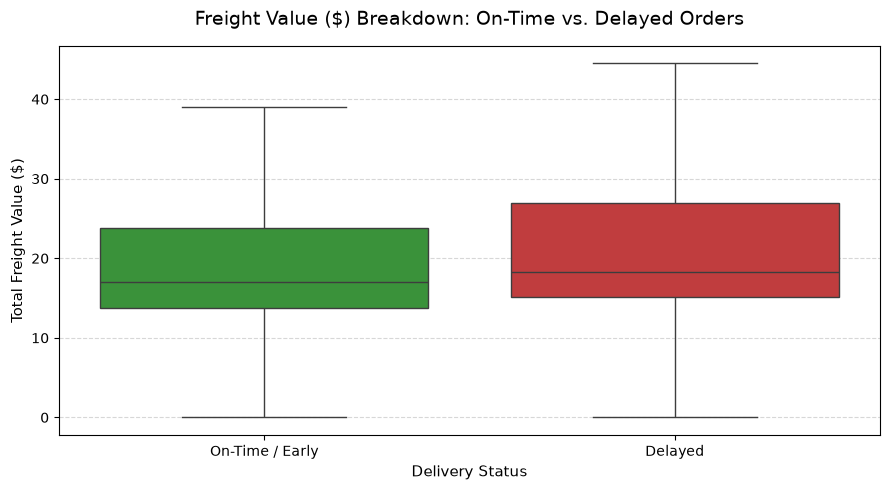

In [112]:
plt.figure(figsize=(9, 5))
ax = sns.boxplot(data=df_delay_freight,x='is_delayed',y='total_freight',palette=['#2ca02c', '#d62728'],showfliers=False,)
plt.title('Freight Value ($) Breakdown: On-Time vs. Delayed Orders',fontsize=14,pad=15)
plt.xlabel('Delivery Status', fontsize=11)
plt.ylabel('Total Freight Value ($)', fontsize=11)
ax.set_xticklabels(['On-Time / Early', 'Delayed'])
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

In [101]:
# Review score distribution
review_dist = (order_reviews_df_c['review_score'].value_counts().sort_index().reset_index())
review_dist.columns = ['review_score', 'review_count']
total_reviews = review_dist['review_count'].sum()
review_dist['percentage'] = (review_dist['review_count'] / total_reviews) * 100
review_dist['cumulative_pct'] = review_dist['percentage'].cumsum()

review_dist['percentage'] = review_dist['percentage'].round(2)
review_dist['cumulative_pct'] = review_dist['cumulative_pct'].round(2)

review_dist

,review_score,review_count,percentage,cumulative_pct
0,1,11424,11.51,11.51
1,2,3151,3.18,14.69
2,3,8179,8.24,22.93
3,4,19142,19.29,42.22
4,5,57328,57.78,100.00


C:\Users\ssasi\AppData\Local\Temp\ipykernel_23880\3113581309.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=review_dist,x='review_score',y='review_count',palette='Blues_r',)


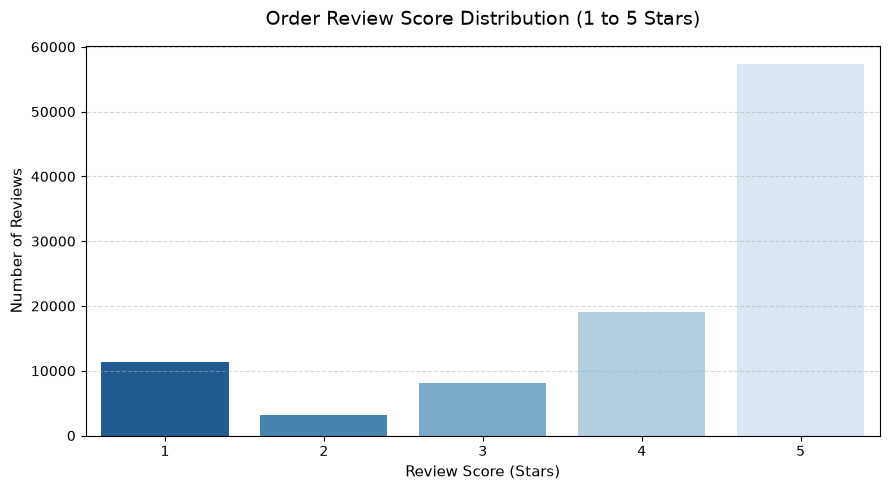

In [102]:
plt.figure(figsize=(9, 5))
sns.barplot(data=review_dist,x='review_score',y='review_count',palette='Blues_r',)
plt.title('Order Review Score Distribution (1 to 5 Stars)', fontsize=14, pad=15)
plt.xlabel('Review Score (Stars)', fontsize=11)
plt.ylabel('Number of Reviews', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

In [106]:
# Reviews vs Delivery delays
df_reviews_delay = pd.merge(order_reviews_df_c[['order_id', 'review_score']],orders_df_c[['order_id','actual_delivery_days','delay','is_delayed','carrier2customer_delivery_days']],
    on='order_id',how='inner')

review_logistics_impact = (df_reviews_delay.groupby('review_score').agg(
        total_reviews=('order_id', 'count'),
        avg_actual_delivery_days=('actual_delivery_days', 'mean'),
        avg_carrier_transit_days=('carrier2customer_delivery_days', 'mean'),
        avg_delay_days=('delay', 'mean'),
        delayed_orders_pct=('is_delayed', lambda x: (x.sum() / x.count()) * 100),
    ).reset_index())

review_logistics_impact.round(2)

,review_score,total_reviews,avg_actual_delivery_days,avg_carrier_transit_days,avg_delay_days,delayed_orders_pct
0,1,11424,20.86,16.18,-4.04,30.15
1,2,3151,16.21,12.24,-8.63,17.65
2,3,8179,13.80,10.23,-10.77,8.53
3,4,19142,11.85,8.66,-12.38,3.41
4,5,57328,10.22,7.38,-13.39,1.85


C:\Users\ssasi\AppData\Local\Temp\ipykernel_23880\1487093586.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=review_logistics_impact,x='review_score',y='delayed_orders_pct',palette='Blues_r')


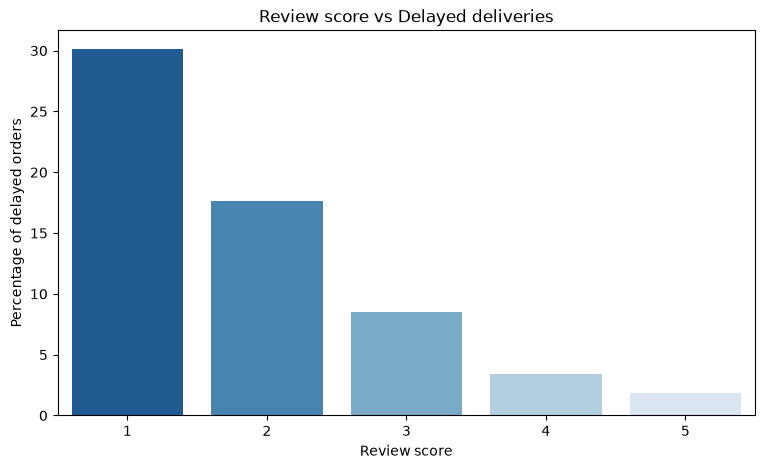

In [107]:
plt.figure(figsize=(9,5))
sns.barplot(data=review_logistics_impact,x='review_score',y='delayed_orders_pct',palette='Blues_r')
plt.title('Review score vs Delayed deliveries')
plt.xlabel('Review score')
plt.ylabel('Percentage of delayed orders')
plt.show()

In [110]:
# Reviews by Product category

df_reviews_category = (order_reviews_df_c[['order_id', 'review_score']].merge(order_items_df_c[['order_id', 'product_id']], on='order_id', how='inner')
    .merge(products_df_c[['product_id', 'product_category_name']], on='product_id', how='inner').merge(product_category_transalation_df_c, on='product_category_name', how='left'))

category_review_summary = (df_reviews_category.groupby('product_category_name_english').agg(
        total_reviews=('review_score', 'count'),
        avg_review_score=('review_score', 'mean'),
        one_star_count=('review_score', lambda x: (x == 1).sum()),
        one_star_pct=('review_score', lambda x: ((x == 1).sum() / x.count()) * 100),
        five_star_count=('review_score',lambda x: ((x == 5).sum())),
        five_star_pct=('review_score', lambda x: ((x == 5).sum() / x.count()) * 100)).reset_index())

category_review_summary = category_review_summary[category_review_summary['total_reviews'] >= 100].copy()

category_review_summary['avg_review_score'] = category_review_summary['avg_review_score'].round(2)
category_review_summary['one_star_pct'] = category_review_summary['one_star_pct'].round(2)
category_review_summary['five_star_pct'] = category_review_summary['five_star_pct'].round(2)

print("Top 10 Highest Rated Categories:")
display(category_review_summary.sort_values(by='avg_review_score', ascending=False).head(10))

print("\nTop 10 Lowest Rated Categories:")
display(category_review_summary.sort_values(by='avg_review_score', ascending=True).head(10))

Top 10 Highest Rated Categories:


,product_category_name_english,total_reviews,avg_review_score,one_star_count,one_star_pct,five_star_count,five_star_pct
8,books_general_interest,549,4.45,39,7.10,398,72.50
10,books_technical,266,4.37,22,8.27,188,70.68
53,luggage_accessories,1088,4.32,80,7.35,705,64.80
37,food_drink,279,4.32,17,6.09,178,63.80
31,fashion_shoes,261,4.23,23,8.81,166,63.60
36,food,495,4.22,51,10.30,313,63.23
66,stationery,2507,4.19,247,9.85,1544,61.59
60,pet_shop,1939,4.19,192,9.90,1196,61.68
14,computers,200,4.18,24,12.00,122,61.00
44,home_appliances,806,4.17,82,10.17,480,59.55



Top 10 Lowest Rated Categories:


,product_category_name_english,total_reviews,avg_review_score,one_star_count,one_star_pct,five_star_count,five_star_pct
57,office_furniture,1687,3.49,355,21.04,620,36.75
30,fashion_male_clothing,131,3.64,34,25.95,68,51.91
34,fixed_telephony,262,3.68,50,19.08,120,45.80
4,audio,361,3.83,60,16.62,190,52.63
47,home_confort,435,3.83,72,16.55,230,52.87
19,construction_tools_safety,193,3.84,35,18.13,100,51.81
40,furniture_living_room,502,3.90,67,13.35,256,51.00
39,furniture_decor,8331,3.90,1260,15.12,4452,53.44
7,bed_bath_table,11137,3.90,1614,14.49,5785,51.94
15,computers_accessories,7849,3.93,1174,14.96,4200,53.51


In [113]:
# Payment mode vs Order value
payment_summary = order_payments_df_c.groupby('payment_type')['payment_value'].agg(count='count',mean='mean',median='median',std='std',sum='sum').reset_index().sort_values(by='mean', ascending=False)
payment_summary

,payment_type,count,mean,median,std,sum
1,credit_card,76795,163.319021,106.87,222.119311,12542084.19
0,boleto,19784,145.034435,93.89,213.581061,2869361.27
2,debit_card,1529,142.570170,89.30,245.793401,217989.79
4,voucher,5775,65.703354,39.28,115.519185,379436.87
3,not_defined,3,0.000000,0.00,0.000000,0.00


C:\Users\ssasi\AppData\Local\Temp\ipykernel_23880\252038848.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=order_payments_df_c, x='payment_type', y='payment_value', showfliers=False,palette='Set2')


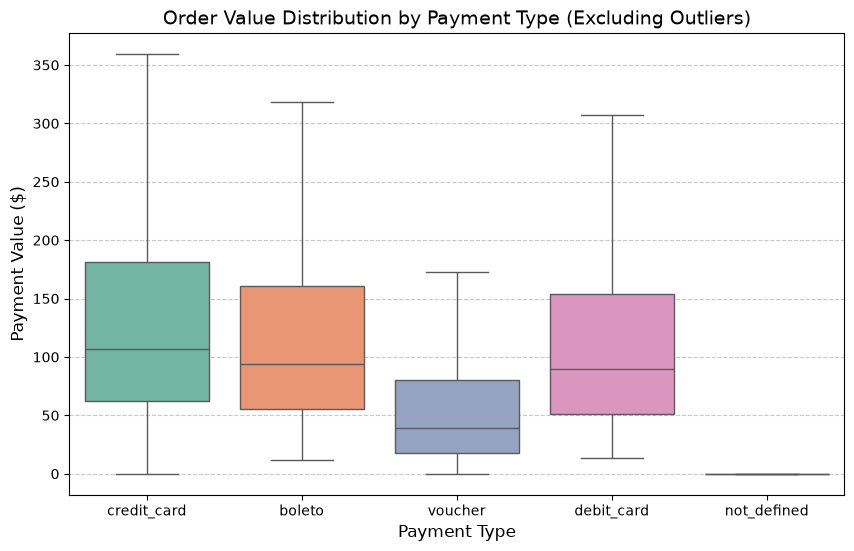

In [114]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=order_payments_df_c, x='payment_type', y='payment_value', showfliers=False,palette='Set2')
plt.title('Order Value Distribution by Payment Type (Excluding Outliers)', fontsize=14)
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Payment Value ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

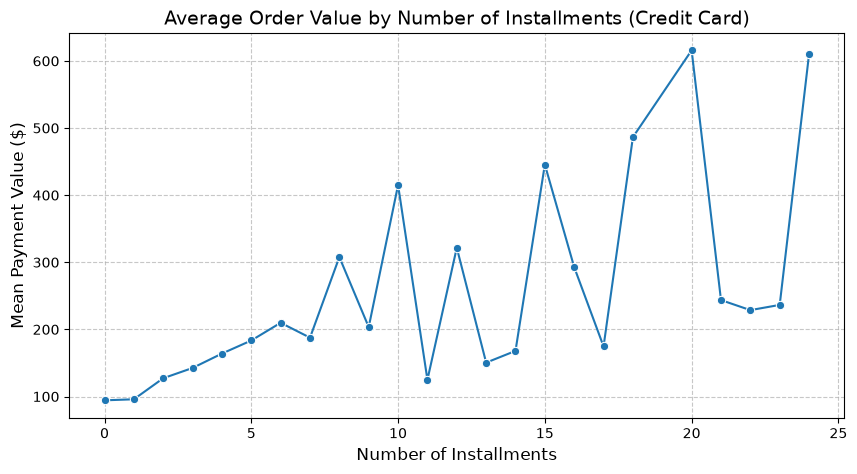

In [115]:
credit_cards = order_payments_df_c[order_payments_df_c['payment_type'] == 'credit_card']

plt.figure(figsize=(10, 5))
sns.lineplot(data=credit_cards, x='payment_installments', y='payment_value', estimator='mean', errorbar=None, marker='o')
plt.title('Average Order Value by Number of Installments (Credit Card)', fontsize=14)
plt.xlabel('Number of Installments', fontsize=12)
plt.ylabel('Mean Payment Value ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [119]:
# Seasonal product category demand
merged_df = orders_df_c.merge(order_items_df_c, on='order_id') \
                       .merge(products_df_c, on='product_id') \
                       .merge(product_category_transalation_df_c, on='product_category_name', how='left')

merged_df = merged_df[merged_df['order_status'] == 'delivered']

merged_df['order_purchase_timestamp'] = pd.to_datetime(merged_df['order_purchase_timestamp'])
merged_df['year_month'] = merged_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

top_categories = merged_df['product_category_name_english'].value_counts().head(5).index

top_cat_df = merged_df[merged_df['product_category_name_english'].isin(top_categories)]

monthly_category_sales = top_cat_df.groupby(['year_month', 'product_category_name_english']).size().reset_index(name='items_sold')
monthly_category_sales

,year_month,product_category_name_english,items_sold
0,2016-09,health_beauty,3
1,2016-10,bed_bath_table,8
2,2016-10,computers_accessories,12
3,2016-10,furniture_decor,65
4,2016-10,health_beauty,40
...,...,...,...
101,2018-08,bed_bath_table,655
102,2018-08,computers_accessories,415
103,2018-08,furniture_decor,430
104,2018-08,health_beauty,835


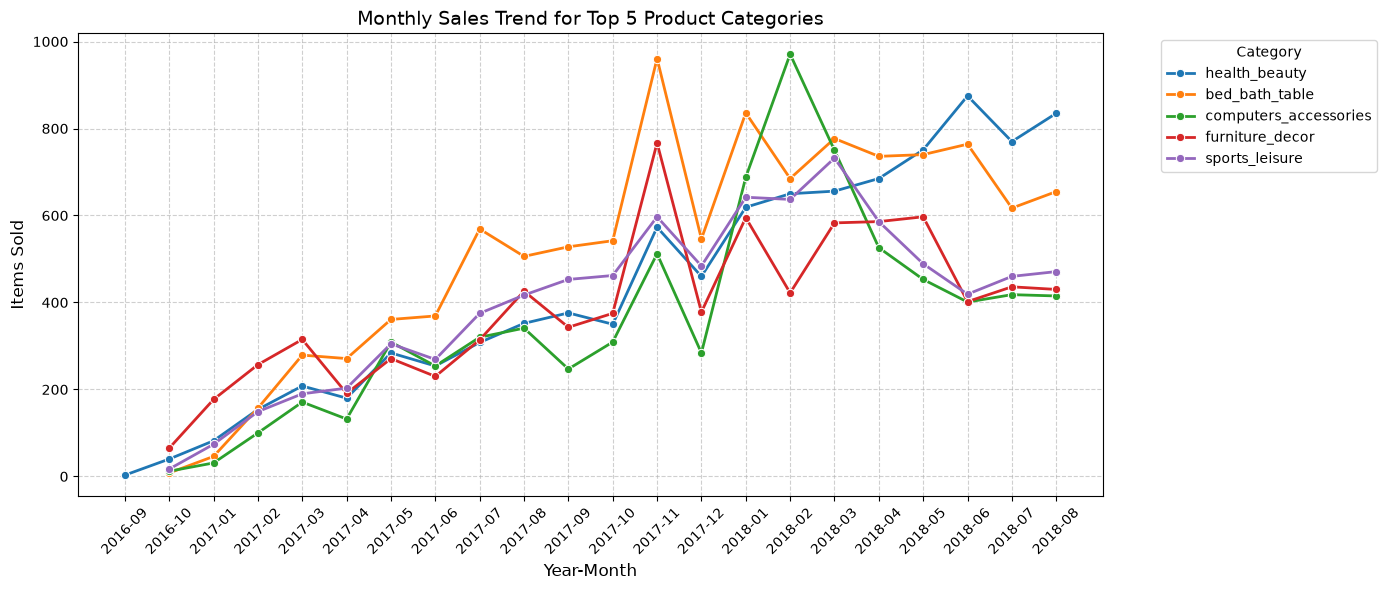

In [120]:
# Plot 1: Monthly Line Plot for Top Categories
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_category_sales, x='year_month', y='items_sold', hue='product_category_name_english', marker='o',linewidth=2)
plt.title('Monthly Sales Trend for Top 5 Product Categories', fontsize=14)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Items Sold', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

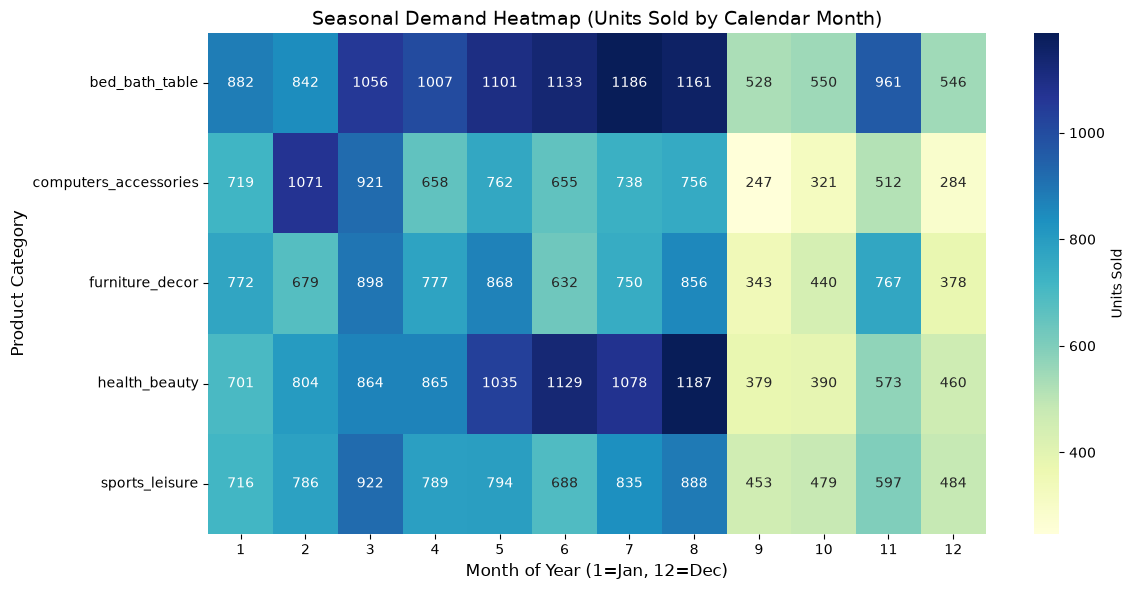

In [125]:
# Seasonal Heatmap: Month (1-12) vs. Category
merged_df['month'] = merged_df['order_purchase_timestamp'].dt.month

heatmap_data = merged_df[merged_df['product_category_name_english'].isin(top_categories)] \
    .pivot_table(index='product_category_name_english', columns='month', values='order_id', aggfunc='count', fill_value=0)
heatmap_data

# Plot 2: Heatmap across calendar months
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='d', cbar_kws={'label': 'Units Sold'})
plt.title('Seasonal Demand Heatmap (Units Sold by Calendar Month)', fontsize=14)
plt.xlabel('Month of Year (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

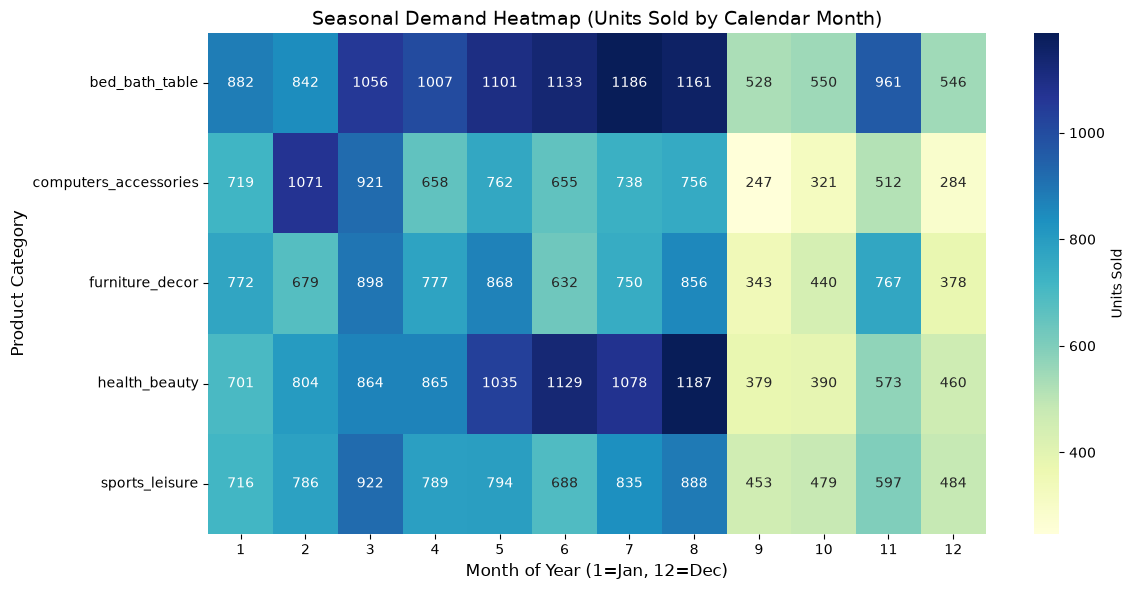

In [129]:
# RFM Analysis
df = orders_df_c[orders_df_c['order_status'] == 'delivered'].merge(customers_df_c, on='customer_id').merge(order_payments_df_c, on='order_id')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg({'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,'order_id': 'nunique','payment_value': 'sum'}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# Calculate RFM Scores (1 to 5)
# Recency: Lower is better -> Labels 5 to 1
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: Handled with rank method if repeat orders are low
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Monetary: Higher is better -> Labels 1 to 5
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Combine into RFM Segment String
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score_Sum'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)
rfm.sort_values(by='RFM_Score_Sum',ascending=False)

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score_Sum
90077,f6db892e508b52b2419ce2fe09628d7c,13,1,384.66,5,5,5,555,15
93326,ffe96c782a5bc522bd8bad3bc638981a,31,1,245.22,5,5,5,555,15
77833,d4f4e1a338c7abd6b74e631887442994,32,1,592.88,5,5,5,555,15
88054,f152b7069661b094652dae554d2a265e,75,1,272.99,5,5,5,555,15
83918,e5d666c254dc4f4d7f205213e00b0cff,47,1,229.37,5,5,5,555,15
...,...,...,...,...,...,...,...,...,...
7832,152a803f01c1cf2f04a0ffc8b42a6fa1,564,1,50.86,1,1,1,111,3
17384,2f773f0baf86e08ef3d039747121abe0,467,1,35.00,1,1,1,111,3
10738,1d383678ba387a5b2df2b186716fc764,480,1,54.61,1,1,1,111,3
1034,02d4b41ec93694d2e59f380190827a3e,409,1,46.00,1,1,1,111,3


--- Customer Count per Segment ---
Segment
Recent Buyers      22357
Loyal Customers    18824
Lost               14986
Champions          14961
At Risk            14803
Needs Attention     7426
Name: count, dtype: int64


C:\Users\ssasi\AppData\Local\Temp\ipykernel_23880\4201239293.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='Blues_r')


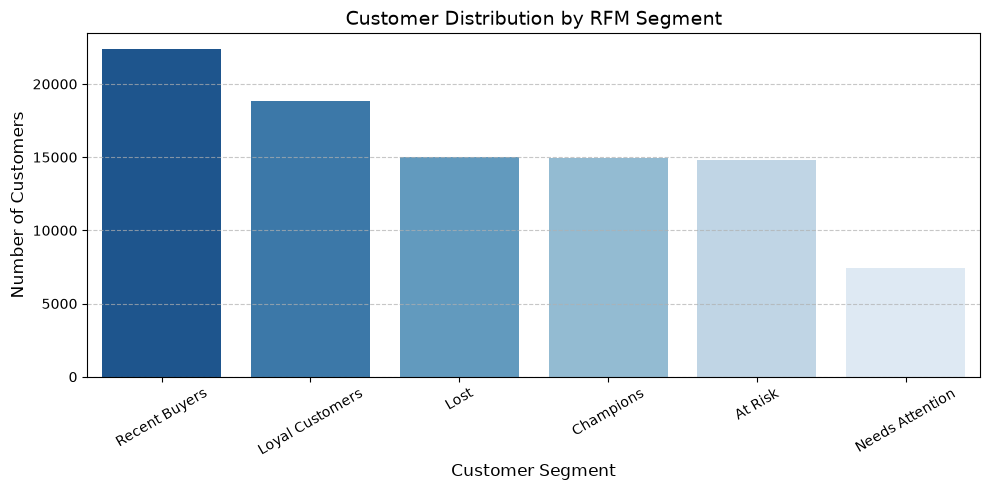

In [127]:
# Define Customer Segments based on R and F Scores
def segment_customer(df):
    r = int(df['R_Score'])
    f = int(df['F_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Recent Buyers'
    elif r <= 2 and f >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Display Summary
print("--- Customer Count per Segment ---")
print(rfm['Segment'].value_counts())

# 6. Visualization: Distribution of Customer Segments
plt.figure(figsize=(10, 5))
sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index, palette='Blues_r')
plt.title('Customer Distribution by RFM Segment', fontsize=14)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [132]:
# Seller performance matrix
df_seller = order_items_df_c.merge(orders_df_c, on='order_id').merge(order_reviews_df_c, on='order_id')

df_seller['order_delivered_customer_date'] = pd.to_datetime(df_seller['order_delivered_customer_date'])
df_seller['order_estimated_delivery_date'] = pd.to_datetime(df_seller['order_estimated_delivery_date'])

df_seller['is_late'] = (df_seller['order_delivered_customer_date'] > df_seller['order_estimated_delivery_date']).astype(int)

seller_matrix = df_seller.groupby('seller_id').agg(
    total_revenue=('price', 'sum'),
    units_sold=('order_item_id', 'count'),
    avg_review_score=('review_score', 'mean'),
    late_delivery_rate=('is_late', 'mean'),
    unique_products=('product_id', 'nunique')).reset_index()
display(seller_matrix)

,seller_id,total_revenue,units_sold,avg_review_score,late_delivery_rate,unique_products
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00,3,3.666667,0.000000,1
1,001cca7ae9ae17fb1caed9dfb1094831,24770.03,236,3.902542,0.050847,11
2,001e6ad469a905060d959994f1b41e4f,250.00,1,1.000000,0.000000,1
3,002100f778ceb8431b7a1020ff7ab48f,1254.40,56,3.982143,0.160714,24
4,003554e2dce176b5555353e4f3555ac8,120.00,1,5.000000,0.000000,1
...,...,...,...,...,...,...
3085,ffcfefa19b08742c5d315f2791395ee5,69.90,1,1.000000,0.000000,1
3086,ffdd9f82b9a447f6f8d4b91554cc7dd3,2101.20,20,4.250000,0.000000,12
3087,ffeee66ac5d5a62fe688b9d26f83f534,1839.86,14,4.214286,0.142857,3
3088,fffd5413c0700ac820c7069d66d98c89,8870.90,60,3.866667,0.116667,29


In [133]:
# Seller Quadrant Categorization
active_sellers = seller_matrix[seller_matrix['units_sold'] >= 10].copy()
active_sellers['on_time_rate'] = (1 - active_sellers['late_delivery_rate']) * 100

revenue_median = active_sellers['total_revenue'].median()
review_median = active_sellers['avg_review_score'].median()

def categorize_seller(row):
    if row['total_revenue'] >= revenue_median and row['avg_review_score'] >= review_median:
        return 'Star Seller'
    elif row['total_revenue'] < revenue_median and row['avg_review_score'] >= review_median:
        return 'High Potential'
    elif row['total_revenue'] >= revenue_median and row['avg_review_score'] < review_median:
        return 'High Volume / At-Risk'
    else:
        return 'Underperformer'

active_sellers['Quadrant'] = active_sellers.apply(categorize_seller, axis=1)
display(active_sellers)

,seller_id,total_revenue,units_sold,avg_review_score,late_delivery_rate,unique_products,on_time_rate,Quadrant
1,001cca7ae9ae17fb1caed9dfb1094831,24770.03,236,3.902542,0.050847,11,94.915254,High Volume / At-Risk
3,002100f778ceb8431b7a1020ff7ab48f,1254.40,56,3.982143,0.160714,24,83.928571,Underperformer
5,004c9cd9d87a3c30c522c48c4fc07416,20234.21,173,4.132948,0.086705,87,91.329480,Star Seller
6,00720abe85ba0859807595bbf045a33b,1007.50,26,3.653846,0.076923,9,92.307692,Underperformer
9,00ee68308b45bc5e2660cd833c3f81cc,20207.00,172,4.331395,0.081395,23,91.860465,Star Seller
...,...,...,...,...,...,...,...,...
3084,ffc470761de7d0232558ba5e786e57b7,1529.13,30,4.300000,0.066667,15,93.333333,High Potential
3086,ffdd9f82b9a447f6f8d4b91554cc7dd3,2101.20,20,4.250000,0.000000,12,100.000000,High Potential
3087,ffeee66ac5d5a62fe688b9d26f83f534,1839.86,14,4.214286,0.142857,3,85.714286,High Potential
3088,fffd5413c0700ac820c7069d66d98c89,8870.90,60,3.866667,0.116667,29,88.333333,High Volume / At-Risk


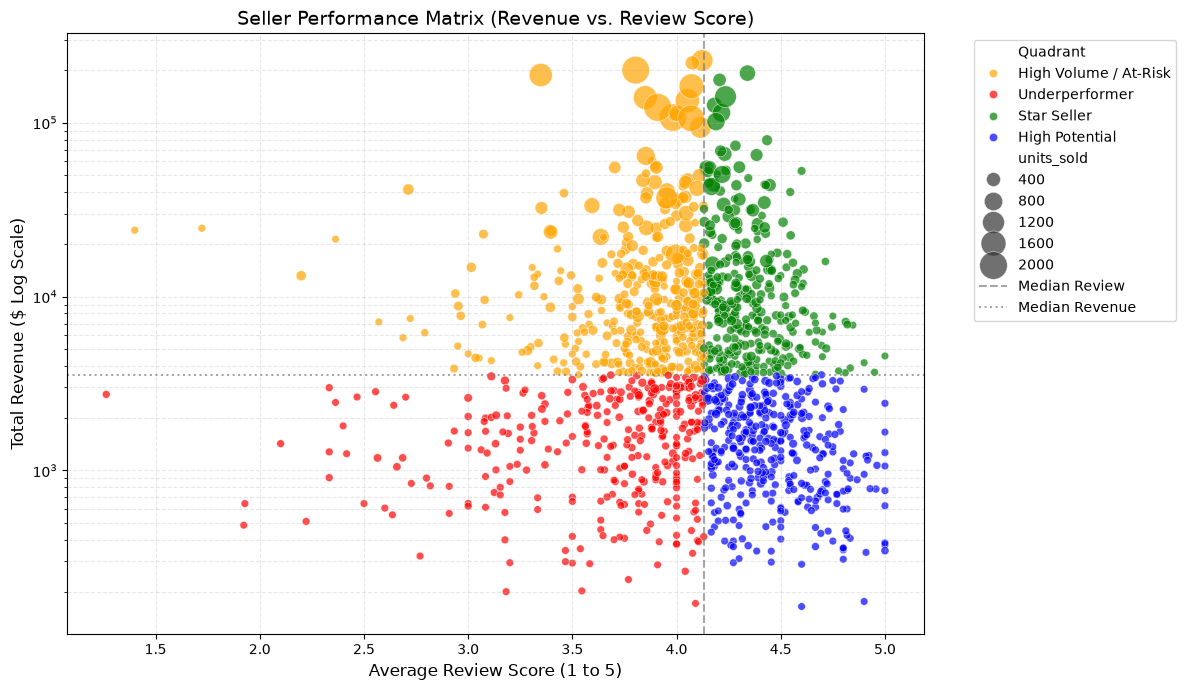

--- Seller Distribution Across Quadrants ---
Quadrant
High Volume / At-Risk    374
High Potential           374
Star Seller              316
Underperformer           315
Name: count, dtype: int64


In [134]:
# Visualization: Seller Performance Matrix Plot
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(data=active_sellers,x='avg_review_score',y='total_revenue',hue='Quadrant',size='units_sold',sizes=(30, 400),palette={'Star Seller': 'green', 'High Potential': 'blue', 'High Volume / At-Risk': 'orange', 'Underperformer': 'red'},alpha=0.7)

# Quadrant Threshold Lines
plt.axvline(x=review_median, color='gray', linestyle='--', alpha=0.7, label='Median Review')
plt.axhline(y=revenue_median, color='gray', linestyle=':', alpha=0.7, label='Median Revenue')

plt.yscale('log')  # Log scale used due to heavy tail in seller revenue distribution
plt.title('Seller Performance Matrix (Revenue vs. Review Score)', fontsize=14)
plt.xlabel('Average Review Score (1 to 5)', fontsize=12)
plt.ylabel('Total Revenue ($ Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print Segment Overview
print("--- Seller Distribution Across Quadrants ---")
print(active_sellers['Quadrant'].value_counts())

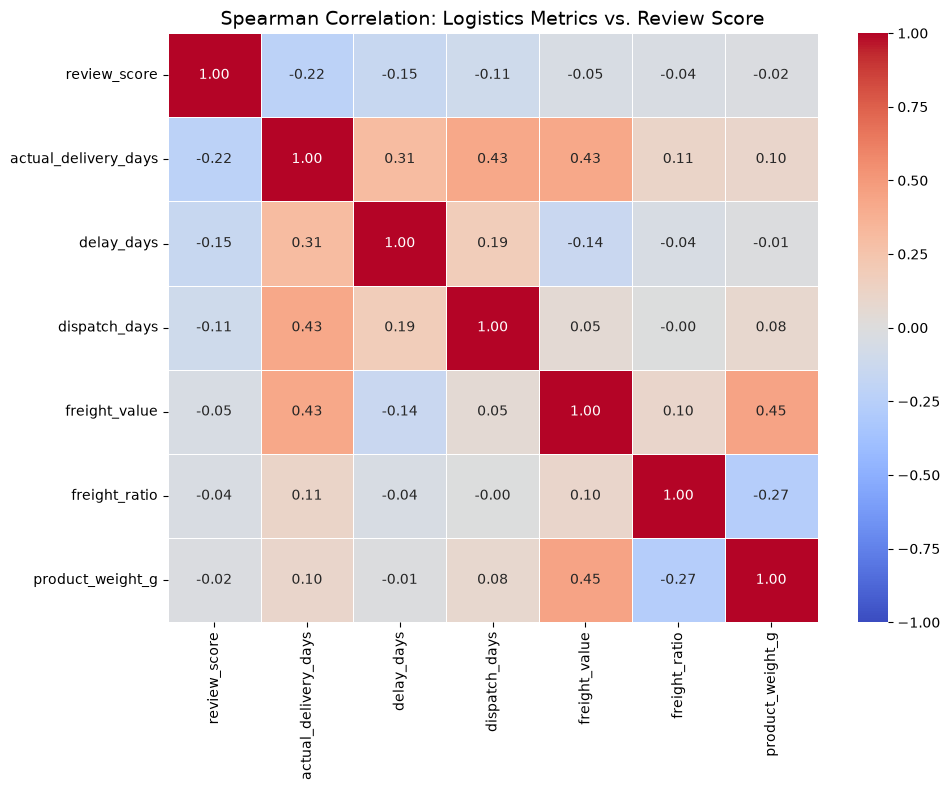

In [137]:
# Logistics & Satisfaction Correlation analysis
logistics_df = orders_df_c[orders_df_c['order_status'] == 'delivered'].merge(order_reviews_df_c[['order_id', 'review_score']], on='order_id').merge(
    order_items_df_c[['order_id', 'product_id', 'price', 'freight_value']], on='order_id').merge(products_df_c[['product_id', 'product_weight_g']], on='product_id')

timestamp_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in timestamp_cols:
    logistics_df[col] = pd.to_datetime(logistics_df[col])


logistics_df['actual_delivery_days'] = (logistics_df['order_delivered_customer_date'] - logistics_df['order_purchase_timestamp']).dt.total_seconds() / 86400.0

logistics_df['delay_days'] = (logistics_df['order_delivered_customer_date'] - logistics_df['order_estimated_delivery_date']).dt.total_seconds() / 86400.0

logistics_df['dispatch_days'] = (logistics_df['order_delivered_carrier_date'] - logistics_df['order_purchase_timestamp']).dt.total_seconds() / 86400.0

logistics_df['freight_ratio'] = logistics_df['freight_value'] / logistics_df['price']

corr_features = ['review_score', 'actual_delivery_days', 'delay_days', 'dispatch_days', 'freight_value', 'freight_ratio', 'product_weight_g']
corr_df = logistics_df[corr_features].dropna()

# Compute Spearman Rank Correlation Matrix
spearman_corr = corr_df.corr(method='spearman')

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Spearman Correlation: Logistics Metrics vs. Review Score', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\ssasi\AppData\Local\Temp\ipykernel_23880\2082427429.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=logistics_df, x='is_late', y='review_score', palette=['g', 'r'],errorbar=None)


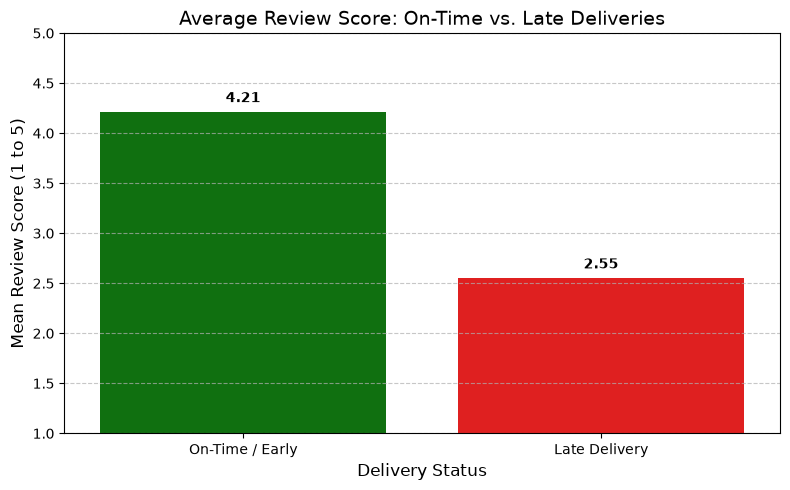

In [138]:
# Impact of Late Delivery on Average Review Score
logistics_df['is_late'] = logistics_df['delay_days'] > 0

plt.figure(figsize=(8, 5))
sns.barplot(data=logistics_df, x='is_late', y='review_score', palette=['g', 'r'],errorbar=None)
plt.title('Average Review Score: On-Time vs. Late Deliveries', fontsize=14)
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Mean Review Score (1 to 5)', fontsize=12)
plt.xticks([0, 1], ['On-Time / Early', 'Late Delivery'])
plt.ylim(1, 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

#    Annotate bars with mean values
means = logistics_df.groupby('is_late')['review_score'].mean()
for i, mean in enumerate(means):
    plt.text(i, mean + 0.1, f"{mean:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()